In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_students = 100

data = {
    "Student_ID": [f"S{i:03d}" for i in range(1, n_students + 1)],
    "Watch_Time": np.random.randint(10, 100, n_students),
    "Completion_Rate": np.random.randint(20, 100, n_students),
    "Replays": np.random.randint(0, 8, n_students),
    "Pauses": np.random.randint(0, 10, n_students),
    "Videos_Watched": np.random.randint(1, 15, n_students),
    "Quiz_Score": np.random.randint(30, 100, n_students)
}

df = pd.DataFrame(data)

df.head()

,Student_ID,Watch_Time,Completion_Rate,Replays,Pauses,Videos_Watched,Quiz_Score
0,S001,61,90,1,7,9,39
1,S002,24,28,7,3,10,98
2,S003,81,20,5,2,14,63
3,S004,70,27,7,8,13,81
4,S005,30,82,6,2,6,39


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Student_ID       100 non-null    object
 1   Watch_Time       100 non-null    int64 
 2   Completion_Rate  100 non-null    int64 
 3   Replays          100 non-null    int64 
 4   Pauses           100 non-null    int64 
 5   Videos_Watched   100 non-null    int64 
 6   Quiz_Score       100 non-null    int64 
dtypes: int64(6), object(1)
memory usage: 5.6+ KB


In [3]:
df.describe()

,Watch_Time,Completion_Rate,Replays,Pauses,Videos_Watched,Quiz_Score
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,56.680000,56.240000,3.620000,3.990000,7.940000,61.850000
std,27.281503,24.101687,2.501636,2.897212,4.067163,19.512428
min,11.000000,20.000000,0.000000,0.000000,1.000000,30.000000
25%,31.000000,32.750000,2.000000,1.750000,5.000000,44.500000
50%,60.500000,55.500000,3.000000,4.000000,7.500000,62.000000
75%,80.250000,78.000000,6.000000,6.250000,12.000000,79.000000
max,99.000000,98.000000,7.000000,9.000000,14.000000,98.000000


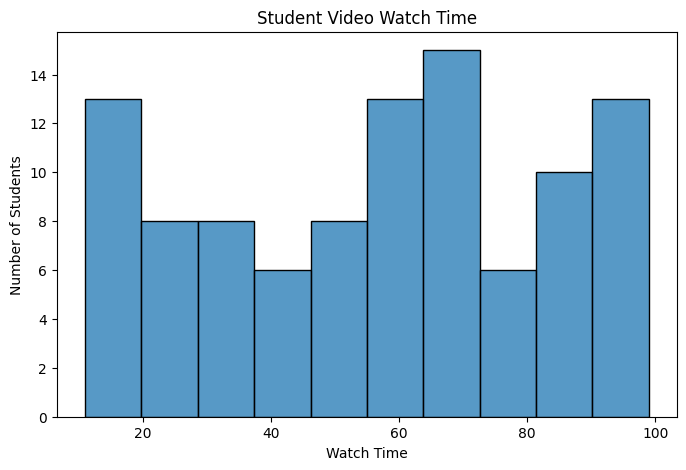

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["Watch_Time"], bins=10)
plt.title("Student Video Watch Time")
plt.xlabel("Watch Time")
plt.ylabel("Number of Students")
plt.show()

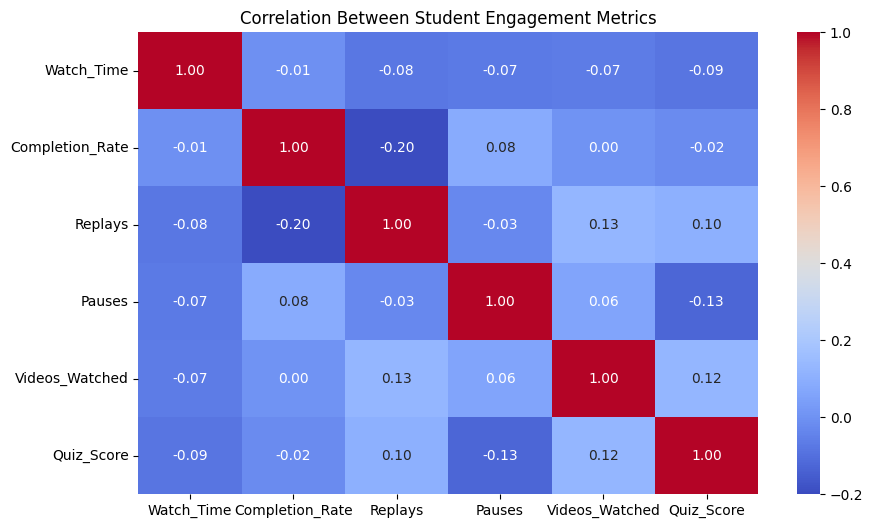

In [5]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df.drop(columns=["Student_ID"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Student Engagement Metrics")
plt.show()

In [6]:
features = [
    "Watch_Time",
    "Completion_Rate",
    "Replays",
    "Pauses",
    "Videos_Watched",
    "Quiz_Score"
]

X = df[features]

X.head()

,Watch_Time,Completion_Rate,Replays,Pauses,Videos_Watched,Quiz_Score
0,61,90,1,7,9,39
1,24,28,7,3,10,98
2,81,20,5,2,14,63
3,70,27,7,8,13,81
4,30,82,6,2,6,39


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 0.15914678,  1.40778846, -1.05259089,  1.04416371,  0.26193688,
        -1.17694805],
       [-1.20391592, -1.17760504,  1.35792259, -0.34342926,  0.50904714,
         1.86199877],
       [ 0.89593743, -1.5112042 ,  0.5544181 , -0.69032751,  1.49748819,
         0.05923371],
       [ 0.49070257, -1.21930493,  1.35792259,  1.39106196,  1.25037793,
         0.98637003],
       [-0.98287873,  1.0741893 ,  0.95617035, -0.69032751, -0.47939391,
        -1.17694805]])

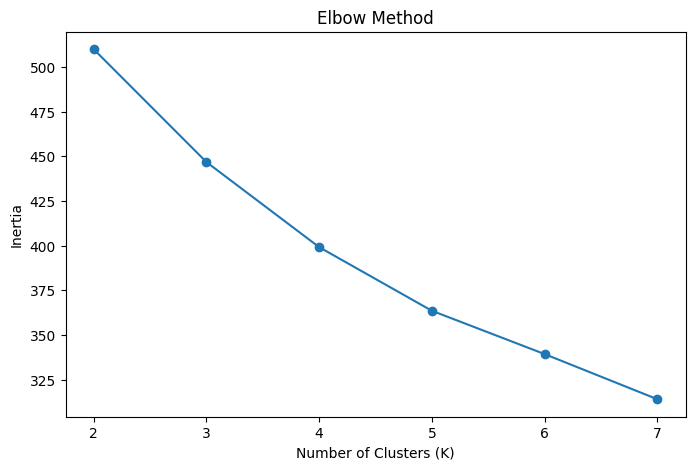

In [8]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 8):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(range(2, 8), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [9]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,Student_ID,Watch_Time,Completion_Rate,Replays,Pauses,Videos_Watched,Quiz_Score,Cluster
0,S001,61,90,1,7,9,39,1
1,S002,24,28,7,3,10,98,0
2,S003,81,20,5,2,14,63,0
3,S004,70,27,7,8,13,81,0
4,S005,30,82,6,2,6,39,1


In [10]:
cluster_summary = df.groupby("Cluster")[features].mean()

cluster_summary

,Watch_Time,Completion_Rate,Replays,Pauses,Videos_Watched,Quiz_Score
Cluster,,,,,,
0,48.838710,43.741935,6.258065,3.806452,9.806452,71.161290
1,68.500000,57.421053,3.131579,4.315789,5.289474,45.763158
2,50.032258,67.290323,1.580645,3.774194,9.322581,72.258065


In [11]:
cluster_names = {
    0: "Low Engagement",
    1: "High Engagement",
    2: "Medium Engagement"
}

df["Engagement_Level"] = df["Cluster"].map(cluster_names)

df.head()

,Student_ID,Watch_Time,Completion_Rate,Replays,Pauses,Videos_Watched,Quiz_Score,Cluster,Engagement_Level
0,S001,61,90,1,7,9,39,1,High Engagement
1,S002,24,28,7,3,10,98,0,Low Engagement
2,S003,81,20,5,2,14,63,0,Low Engagement
3,S004,70,27,7,8,13,81,0,Low Engagement
4,S005,30,82,6,2,6,39,1,High Engagement


In [12]:
df["Engagement_Level"].value_counts()

,count
Engagement_Level,
High Engagement,38
Low Engagement,31
Medium Engagement,31


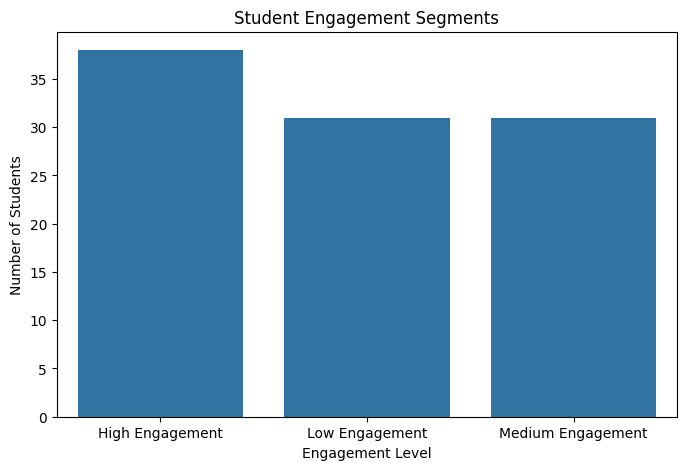

In [13]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Engagement_Level"
)

plt.title("Student Engagement Segments")
plt.xlabel("Engagement Level")
plt.ylabel("Number of Students")
plt.show()

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

X_pca.shape

(100, 2)

In [15]:
df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

df.head()

,Student_ID,Watch_Time,Completion_Rate,Replays,Pauses,Videos_Watched,Quiz_Score,Cluster,Engagement_Level,PCA1,PCA2
0,S001,61,90,1,7,9,39,1,High Engagement,-1.866844,1.334078
1,S002,24,28,7,3,10,98,0,Low Engagement,2.753379,0.034253
2,S003,81,20,5,2,14,63,0,Low Engagement,1.425163,-0.891619
3,S004,70,27,7,8,13,81,0,Low Engagement,1.852518,0.599776
4,S005,30,82,6,2,6,39,1,High Engagement,-0.205207,0.234124


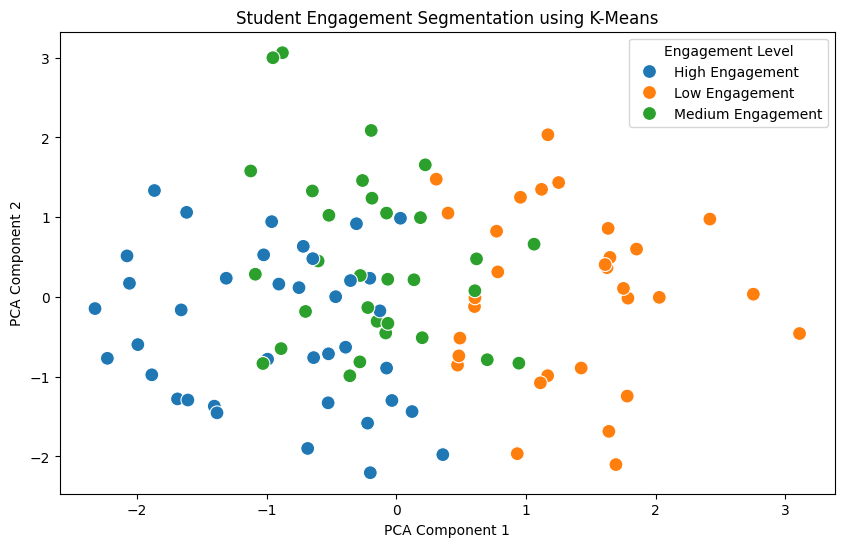

In [16]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Engagement_Level",
    s=100
)

plt.title("Student Engagement Segmentation using K-Means")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Engagement Level")
plt.show()

In [17]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df["Cluster"])

print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.137


In [18]:
final_df = df[
    [
        "Student_ID",
        "Watch_Time",
        "Completion_Rate",
        "Replays",
        "Pauses",
        "Videos_Watched",
        "Quiz_Score",
        "Engagement_Level"
    ]
]

final_df.head(10)

,Student_ID,Watch_Time,Completion_Rate,Replays,Pauses,Videos_Watched,Quiz_Score,Engagement_Level
0,S001,61,90,1,7,9,39,High Engagement
1,S002,24,28,7,3,10,98,Low Engagement
2,S003,81,20,5,2,14,63,Low Engagement
3,S004,70,27,7,8,13,81,Low Engagement
4,S005,30,82,6,2,6,39,High Engagement
5,S006,92,30,3,8,10,48,High Engagement
6,S007,96,27,6,1,10,87,Low Engagement
7,S008,84,54,2,1,6,30,High Engagement
8,S009,84,54,7,1,1,98,Low Engagement
9,S010,97,52,2,5,4,33,High Engagement


In [19]:
final_df["Engagement_Level"].value_counts()

,count
Engagement_Level,
High Engagement,38
Low Engagement,31
Medium Engagement,31


In [20]:
lecture_text = """
Machine Learning is a subset of Artificial Intelligence that enables
computers to learn patterns from data and make predictions or decisions
without being explicitly programmed for every task.

There are three major types of machine learning: supervised learning,
unsupervised learning, and reinforcement learning.

Supervised learning uses labelled data to train a model. The model learns
the relationship between input features and known output labels.
Classification and regression are common supervised learning tasks.

Classification is used when the output is a category. For example,
predicting whether an email is spam or not spam is a classification problem.

Regression is used when the output is a continuous numerical value.
Predicting house prices based on features such as area, location, and
number of rooms is an example of regression.

Unsupervised learning works with unlabeled data. The objective is to find
hidden patterns or groups in the data. Clustering is a common
unsupervised learning technique.

K-Means is a popular clustering algorithm. It divides data points into
K groups called clusters. Each cluster is represented by a centroid.
The algorithm assigns data points to the nearest centroid and repeatedly
updates the centroids until the clusters become stable.

Classification and regression are different because classification
predicts discrete categories, while regression predicts continuous values.

Machine learning models are usually evaluated using suitable performance
metrics. Accuracy, precision, recall, and F1-score are commonly used for
classification problems.
"""

print(lecture_text)


Machine Learning is a subset of Artificial Intelligence that enables
computers to learn patterns from data and make predictions or decisions
without being explicitly programmed for every task.

There are three major types of machine learning: supervised learning,
unsupervised learning, and reinforcement learning.

Supervised learning uses labelled data to train a model. The model learns
the relationship between input features and known output labels.
Classification and regression are common supervised learning tasks.

Classification is used when the output is a category. For example,
predicting whether an email is spam or not spam is a classification problem.

Regression is used when the output is a continuous numerical value.
Predicting house prices based on features such as area, location, and
number of rooms is an example of regression.

Unsupervised learning works with unlabeled data. The objective is to find
hidden patterns or groups in the data. Clustering is a common
unsupervis

In [21]:
import re

sentences = re.split(r'(?<=[.!?])\s+', lecture_text.strip())

chunks = []

chunk_size = 3

for i in range(0, len(sentences), chunk_size):
    chunk = " ".join(sentences[i:i + chunk_size])
    chunks.append(chunk)

print("Number of chunks:", len(chunks))

for i, chunk in enumerate(chunks):
    print(f"\nChunk {i}:")
    print(chunk)

Number of chunks: 7

Chunk 0:
Machine Learning is a subset of Artificial Intelligence that enables
computers to learn patterns from data and make predictions or decisions
without being explicitly programmed for every task. There are three major types of machine learning: supervised learning,
unsupervised learning, and reinforcement learning. Supervised learning uses labelled data to train a model.

Chunk 1:
The model learns
the relationship between input features and known output labels. Classification and regression are common supervised learning tasks. Classification is used when the output is a category.

Chunk 2:
For example,
predicting whether an email is spam or not spam is a classification problem. Regression is used when the output is a continuous numerical value. Predicting house prices based on features such as area, location, and
number of rooms is an example of regression.

Chunk 3:
Unsupervised learning works with unlabeled data. The objective is to find
hidden patterns or

In [22]:
!pip install -q sentence-transformers

In [23]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = embedding_model.encode(chunks)

print("Embedding shape:", embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding shape: (7, 384)


In [24]:
!pip install -q faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 27.2 MB/s eta 0:00:00


In [25]:
import faiss
import numpy as np

In [26]:
embeddings = np.array(embeddings).astype("float32")

dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(embeddings)

print("Number of vectors:", index.ntotal)

Number of vectors: 7


In [27]:
def search_lecture(question, top_k=3):

    # Convert question into embedding
    question_embedding = embedding_model.encode([question])
    question_embedding = np.array(question_embedding).astype("float32")

    # Search similar chunks
    distances, indices = index.search(question_embedding, top_k)

    results = []

    for i in indices[0]:
        results.append(chunks[i])

    return results

In [28]:
question = "What is K-Means clustering?"

results = search_lecture(question)

for i, result in enumerate(results):
    print(f"\nResult {i+1}:")
    print(result)


Result 1:
K-Means is a popular clustering algorithm. It divides data points into
K groups called clusters. Each cluster is represented by a centroid.

Result 2:
Unsupervised learning works with unlabeled data. The objective is to find
hidden patterns or groups in the data. Clustering is a common
unsupervised learning technique.

Result 3:
The algorithm assigns data points to the nearest centroid and repeatedly
updates the centroids until the clusters become stable. Classification and regression are different because classification
predicts discrete categories, while regression predicts continuous values. Machine learning models are usually evaluated using suitable performance
metrics.


In [29]:
question = "What is supervised learning?"

results = search_lecture(question)

for i, result in enumerate(results):
    print(f"\nResult {i+1}:")
    print(result)


Result 1:
The model learns
the relationship between input features and known output labels. Classification and regression are common supervised learning tasks. Classification is used when the output is a category.

Result 2:
Machine Learning is a subset of Artificial Intelligence that enables
computers to learn patterns from data and make predictions or decisions
without being explicitly programmed for every task. There are three major types of machine learning: supervised learning,
unsupervised learning, and reinforcement learning. Supervised learning uses labelled data to train a model.

Result 3:
Unsupervised learning works with unlabeled data. The objective is to find
hidden patterns or groups in the data. Clustering is a common
unsupervised learning technique.


In [30]:
def get_context(question, top_k=3):

    results = search_lecture(question, top_k)

    context = "\n\n".join(results)

    return context

In [31]:
question = "What is K-Means clustering?"

context = get_context(question)

print(context)

K-Means is a popular clustering algorithm. It divides data points into
K groups called clusters. Each cluster is represented by a centroid.

Unsupervised learning works with unlabeled data. The objective is to find
hidden patterns or groups in the data. Clustering is a common
unsupervised learning technique.

The algorithm assigns data points to the nearest centroid and repeatedly
updates the centroids until the clusters become stable. Classification and regression are different because classification
predicts discrete categories, while regression predicts continuous values. Machine learning models are usually evaluated using suitable performance
metrics.


In [32]:
!pip install -q huggingface_hub

In [33]:
from huggingface_hub import InferenceClient

In [43]:
from google.colab import userdata

HF_TOKEN = userdata.get("pblm1")

print("Token loaded:", HF_TOKEN is not None)

Token loaded: True


In [47]:
from huggingface_hub import InferenceClient

client = InferenceClient(
    provider="auto",
    api_key=HF_TOKEN
)

print("LLM client connected successfully!")

LLM client connected successfully!


In [49]:
def generate_answer(question):

    context = get_context(question, top_k=3)

    prompt = f"""
You are an AI course guide for students.

Use ONLY the lecture content below to answer the question.

Lecture Content:
{context}

Student Question:
{question}

If the answer is not present in the lecture,
say "I could not find this information in the lecture."

Answer in simple English.
"""

    response = client.chat_completion(
        model="openai/gpt-oss-120b",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        max_tokens=200
    )

    return response.choices[0].message.content

In [48]:
response = client.chat_completion(
    model="openai/gpt-oss-120b",
    messages=[
        {
            "role": "user",
            "content": "What is machine learning? Explain in simple English."
        }
    ],
    max_tokens=100
)

print(response.choices[0].message.content)

**Machine learning (ML) is a way to teach computers how to do a job by learning


In [50]:
question = "What is K-Means clustering?"

answer = generate_answer(question)

print("Student:", question)
print("\nAI Course Guide:")
print(answer)

Student: What is K-Means clustering?

AI Course Guide:
K‑Means clustering is a popular unsupervised‑learning method that groups data points into **K** separate clusters.  
Each cluster has a **centroid** (the average position of the points in that cluster).  
The algorithm works by:

1. Assigning every data point to the nearest centroid.  
2. Recomputing the centroids based on the points assigned to each cluster.  
3. Repeating steps 1 and 2 until the clusters stop changing (they become stable).  

In short, K‑Means splits the data into K groups, using centroids to represent each group.


In [51]:
!pip install -q gradio

In [52]:
import gradio as gr

def course_guide(question):
    if not question.strip():
        return "Please enter a question."

    return generate_answer(question)

demo = gr.Interface(
    fn=course_guide,
    inputs=gr.Textbox(
        label="Ask your ML Lecture Question",
        placeholder="Example: What is K-Means clustering?"
    ),
    outputs=gr.Textbox(
        label="AI Course Guide"
    ),
    title="🎓 AI Course Guide",
    description="Ask questions based on the Machine Learning lecture."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://83e2a73ddcb0db2804.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
